<a href="https://colab.research.google.com/github/Threksha/Employee-Performance-Analysis-and-Prediction/blob/main/Employee_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement:**

### **Title:** Employee Performance Analysis and Prediction
### **Dataset:** https://www.kaggle.com/datasets/ziya07/employee-performance-dataset

### **Objective:**
The goal of this project is to analyze, predict, and segment employee performance based on demographic, experience, and departmental data. Using the employee performance dataset, we aim to provide actionable insights for HR management and decision-making.

## **Key Tasks:**

### **Data Preprocessing:**

Cleaned the dataset by handling missing values, encoding categorical variables, and scaling numeric features to make the data model-ready.

### **Exploratory Data Analysis (EDA):**

Performed 10 visual analyses to understand distributions, trends, and relationships between employee features (age, experience, education, department) and performance metrics.

### **Classification:**

Predicted the performance category of employees (e.g., high, medium, low) using algorithms such as Decision Tree, Naive Bayes, and Random Forest.

Evaluated models to identify the most accurate predictor of employee performance.

### **Regression:**

Predicted the continuous performance score using Linear Regression and Random Forest Regression.

This helps HR quantify expected performance based on employee features.

### **Clustering:**

Applied K-Means and Hierarchical Clustering to segment employees into distinct groups based on similarities in age, experience, education, department, and performance.

Clusters provide insight into natural employee groupings for targeted interventions, training, or promotions.

### Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, mean_squared_error, r2_score
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

### Loading Dataset

In [ ]:
df = pd.read_csv("combined_employee_dataset_1.csv")
print("Shape:", df.shape)
display(df.head())
#First few rows to preview the data

Shape: (791, 6)


,age,years_experience,education_level,department,performance_score,performance_category
0,58,23,High School,Finance,10,Excellent
1,48,39,Bachelor,HR,6,Good
2,34,15,High School,HR,5,Average
3,27,29,PhD,HR,4,Average
4,40,36,PhD,Finance,2,Poor


In [ ]:
print("\n--- Info ---")
display(df.info())
print("\n--- Describe (numeric) ---")
display(df.describe().T)
#Statistics summary


--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 791 entries, 0 to 790
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   age                   791 non-null    int64 
 1   years_experience      791 non-null    int64 
 2   education_level       791 non-null    object
 3   department            791 non-null    object
 4   performance_score     791 non-null    int64 
 5   performance_category  791 non-null    object
dtypes: int64(3), object(3)
memory usage: 37.2+ KB


None


--- Describe (numeric) ---


,count,mean,std,min,25%,50%,75%,max
age,791.0,39.867257,11.867681,20.0,29.0,41.0,51.0,59.0
years_experience,791.0,21.031606,11.467412,1.0,11.0,22.0,32.0,39.0
performance_score,791.0,5.495575,2.927766,1.0,3.0,5.0,8.0,10.0


In [ ]:
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
print("Columns:", df.columns.tolist())
#Print the cleaned list of column names

Columns: ['age', 'years_experience', 'education_level', 'department', 'performance_score', 'performance_category']


In [ ]:
possible_targets = [c for c in df.columns if "perf" in c or "rating" in c or "score" in c or "performance" in c]
print("Possible target columns:", possible_targets)
#search columns for likely target names containing keywords (perf, rating, score, performance).
#print possible target columns

Possible target columns: ['performance_score', 'performance_category']


In [ ]:
if len(possible_targets) > 0:
    TARGET = possible_targets[0]
    print("Using detected target:", TARGET)
else:
    raise ValueError("No obvious target column found. Set TARGET = 'your_target_column' manually.")

Using detected target: performance_score


In [ ]:
print("\nTarget dtype:", df[TARGET].dtype)
print(df[TARGET].value_counts(dropna=False).head(20))
#Top 20 value counts (including NaNs) for the target column to inspect its distribution.


Target dtype: int64
performance_score
10    88
3     87
1     87
7     85
5     81
9     77
2     74
8     72
6     71
4     69
Name: count, dtype: int64


## **Data Preprocessing:**

- ### **Data Cleaning (Checking for missing values)**

In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
print("\nMissing values (top 20):")
display(missing.head(20))


Missing values (top 20):


,0
age,0
years_experience,0
education_level,0
department,0
performance_score,0
performance_category,0


In [ ]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object","category"]).columns.tolist()
# remove target from feature lists
if TARGET in num_cols: num_cols.remove(TARGET)
if TARGET in cat_cols: cat_cols.remove(TARGET)

print("\nNumeric cols:", num_cols)
print("Categorical cols:", cat_cols)


Numeric cols: ['age', 'years_experience']
Categorical cols: ['education_level', 'department', 'performance_category']


# **Exploratory Data Analysis**

## 1. Pie Chart(Distribution of dept)

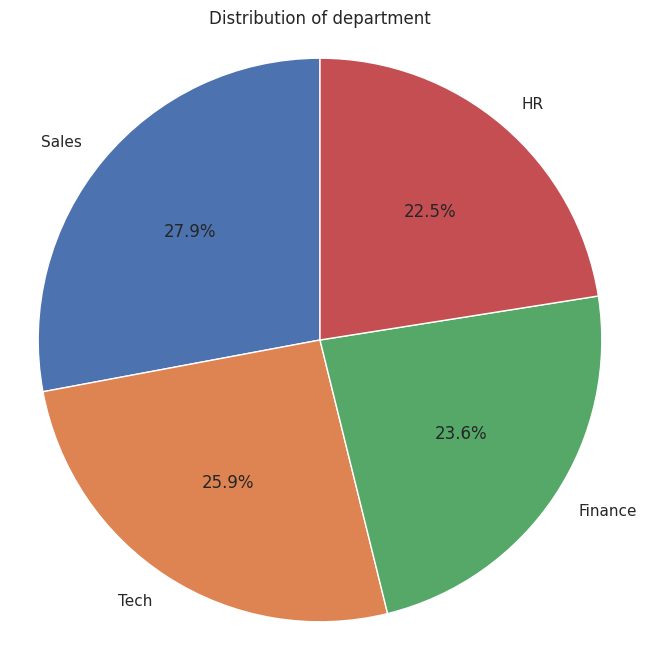

In [ ]:
col = 'department'
counts = df[col].value_counts()

labels = counts.index.tolist()
sizes = counts.values.tolist()

plt.figure(figsize=(8,8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title(f'Distribution of {col}')
plt.axis('equal')
plt.show()

## Inference
- All departments are almost equally distributed.
- Sales department occupies first place where as HR dept last place

## 2. Bar Graph

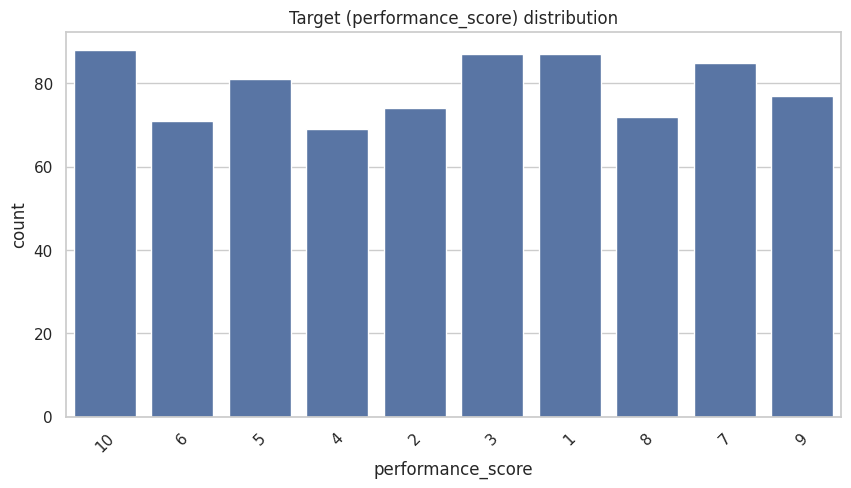

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x=df[TARGET].astype(str))
plt.title(f"Target ({TARGET}) distribution")
plt.xticks(rotation=45)
plt.show()

## Inference
- Highest frequency scores:
  Score 3 and Score 9 have the most occurrences, each close to 90.
- Lowest frequency scores:
  Score 4 and Score 6 have the fewest occurrences, slightly above 70.
- Score range:
  Scores span from 1 to 10, showing full utilization of the rating scale.
- Distribution shape:
  The spread is non-uniform, with peaks at 3 and 9.




## 3. Pareto(Performance score vs count)

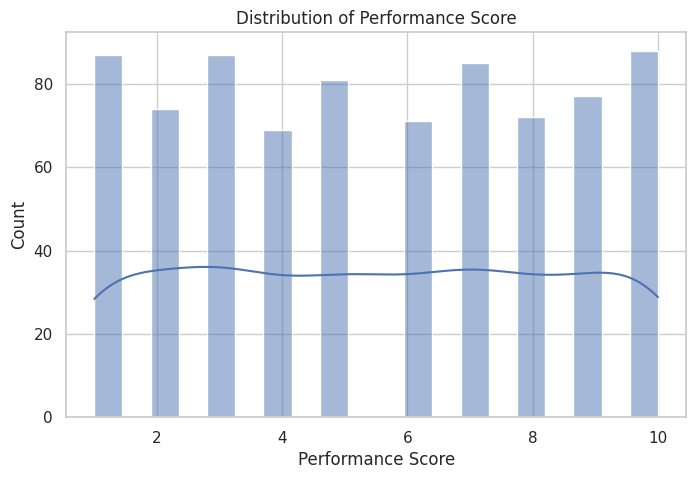

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["performance_score"], kde=True, bins=20)
plt.title("Distribution of Performance Score")
plt.xlabel("Performance Score")
plt.ylabel("Count")
plt.show()

 ## Inference(Performance score vs count-Pareto)
 - Performance scores are uniformly distributed across the range of 1 to 10.
-Each score has a similar count (roughly 60–90), indicating no dominant or rare score.
- The smooth density curve shows **no skewness**, suggesting **balanced** and unbiased scoring.
- This implies a fair evaluation system with diverse performance levels across the dataset.




## 4. Scatter Plot (Age vs performance Score)

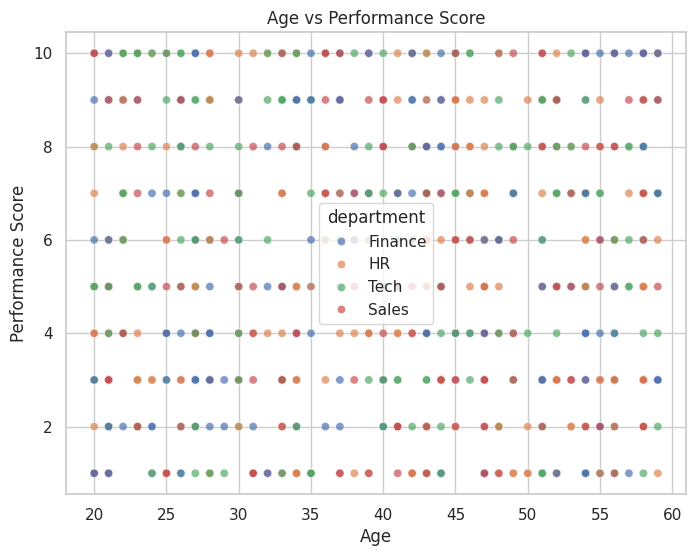

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="age", y="performance_score", hue="department", alpha=0.7)
plt.title("Age vs Performance Score")
plt.xlabel("Age")
plt.ylabel("Performance Score")
plt.show()

## Inference(Age vs performance score-Scatter plot)
- **No strong age-performance correlation**: Performance scores are spread across all age groups without a clear upward or downward trend.
-  **Departmental diversity:** All four departments (Finance, HR, Tech, Sales) show a wide range of scores across ages, suggesting performance is **not department-specific.**
- Score consistency:Most scores cluster between 4 and 9, regardless of age or department.
- **Balanced workforce:** The distribution implies that both younger and older employees contribute comparably to performance outcomes.


## 5. Box Plot(Performance score vs Experience)

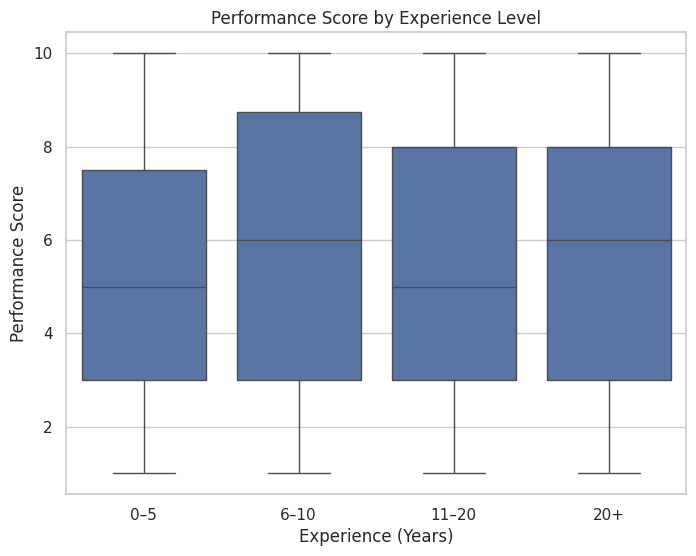

In [ ]:
df["exp_bin"] = pd.cut(df["years_experience"],
                       bins=[0,5,10,20,40],
                       labels=["0–5", "6–10", "11–20", "20+"])

plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="exp_bin", y="performance_score")
plt.title("Performance Score by Experience Level")
plt.xlabel("Experience (Years)")
plt.ylabel("Performance Score")
plt.show()

## Inference(Performance score vs Experience)
- **Median scores are consistent** across all experience groups, suggesting stable performance regardless of tenure.
- Outliers are present in all groups, indicating individual deviations but not systemic trends.
-  This implies that while performance is generally stable across experience levels, **seasoned employees tend to perform more consistently.**


## 6. Count Plot (Performance Category Distribution Across Departments)

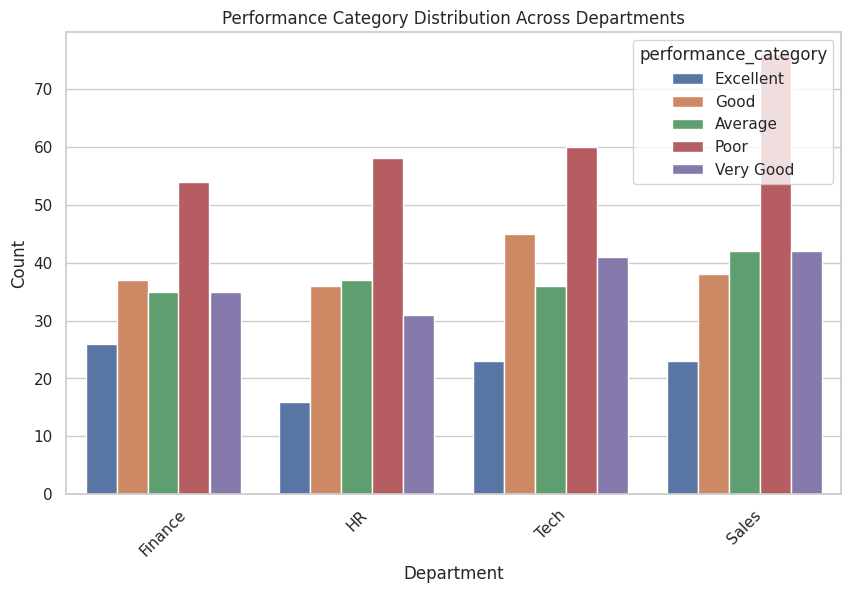

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="department", hue="performance_category")
plt.title("Performance Category Distribution Across Departments")
plt.xticks(rotation=45)
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()

## Inference(Performance category distribution across Departments)
-  **Tech department** excels in the **"Very Good"** category, showing strong overall performance.
-  **Sales department **has the highest count in **"Poor"**, suggesting room for improvement.
-  All departments show a mix of performance categories, indicating varied individual contributions.




## 7. Bar Plot (Education level vs Avg Performance Score by Education Level)

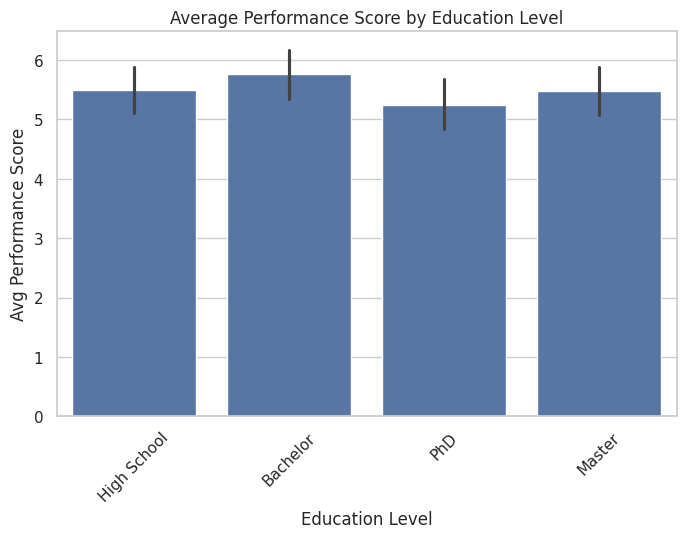

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="education_level", y="performance_score", estimator='mean')
plt.title("Average Performance Score by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Avg Performance Score")
plt.xticks(rotation=45)
plt.show()

## Inference(Average Performance Score by Education Level)
-  Employees with a **Bachelor’s degree perform best on average**, followed closely by those with a **Master’s.**
-  Surprisingly, **PhD holders and High School graduates** show **slightly lower** average scores, which may reflect overqualification, role mismatch, or limited scope for impact.
-  The error bars suggest some variability, but the overall trend favors mid-tier academic qualifications.
-  This insight can guide hiring strategies—prioritizing Bachelor's and Master's candidates for roles where performance is critical.


## 8. Correlation Heatmap (age,experience(yrs),performance_score)

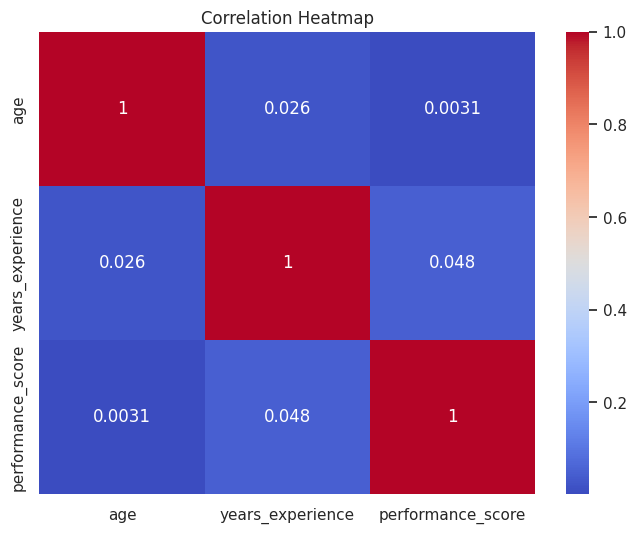

In [ ]:
plt.figure(figsize=(8,6))
numeric_cols = ["age", "years_experience", "performance_score"]
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Inference (Correlation Heatmap)
-  **Very low correlations:** Age and performance score (0.0031), and years of experience and performance score (0.048) show almost no linear relationship.
-  **Age vs experience correlation** is also **weak (0.026)**, suggesting inconsistent career trajectories or varied entry points.
- **Performance appears independent of both age and experience**, implying that other factors—like skills, motivation, or role fit—may drive outcomes.
-  This insight discourages assumptions that older or more experienced employees perform better, supporting merit-based evaluations.


## 9. Pair Plot (age,experience(yrs),performance score)

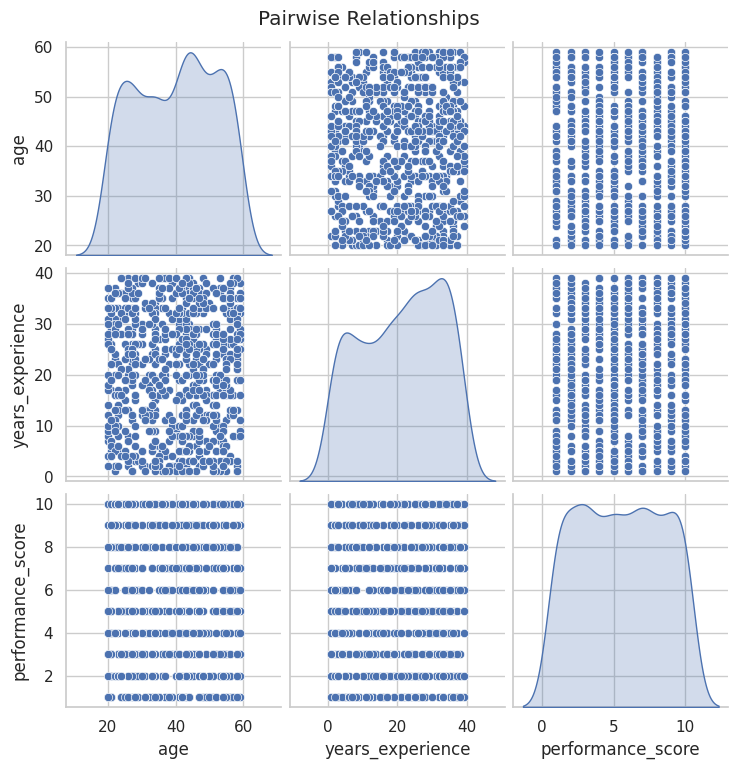

In [ ]:
sns.pairplot(df[["age", "years_experience", "performance_score"]],
             diag_kind="kde")
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

## Inference (Pair plot)
-  **No clear linear relationship** between age, experience, and performance **score—scatterplots** show **wide dispersion**.
-  **Age and experience** distributions are **skewed right**, indicating more younger and less experienced individuals.
-  Performance scores are fairly uniform, with no strong clustering by age or experience.
-  This suggests that performance is **largely independent of age and tenure, reinforcing the value of skill-based evaluation over seniority.**


## 10. Histogram(age vs count)

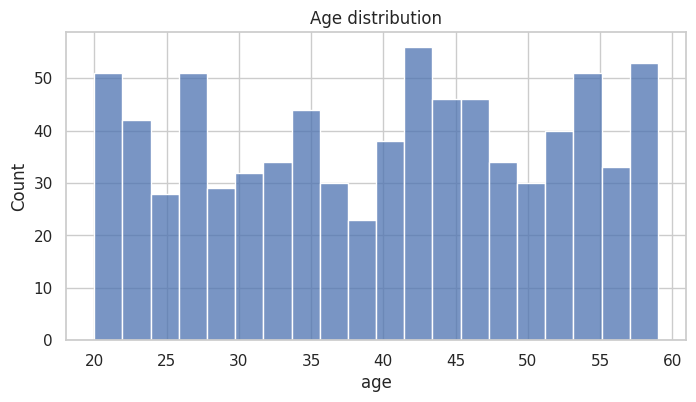

In [ ]:
if "age" in df.columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df['age'].dropna(), bins=20)
    plt.title("Age distribution")
    plt.show()

## Inference(age vs count)
-  The **age spread is relatively uniform,** with individuals fairly evenly distributed across age groups from 20 to 60.
-  Slight fluctuations suggest **no dominant age group**, though some bins (e.g., 30–35 or 40–45) may have marginally higher counts.
-  This indicates a balanced workforce in terms of age, which can support diverse perspectives and experience levels.


## 11. Violin Plot (Performance score vs age,experience (yrs))

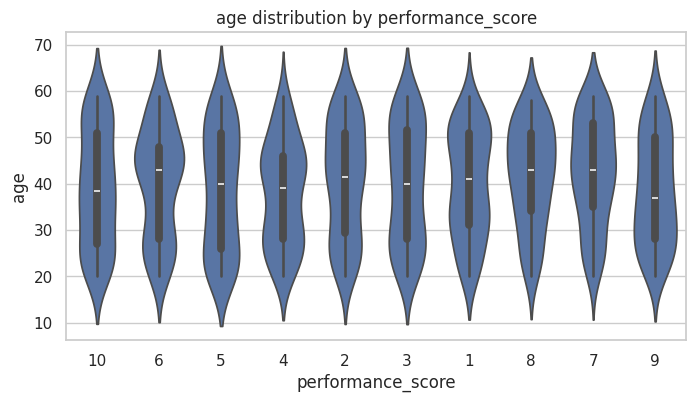

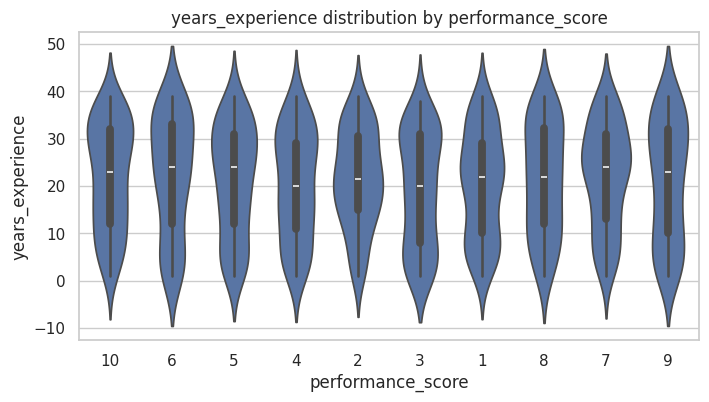

In [ ]:
for col in num_cols[:3]:
    plt.figure(figsize=(8,4))
    sns.violinplot(x=df[TARGET].astype(str), y=df[col])
    plt.title(f"{col} distribution by {TARGET}")
    plt.show()

## Inference (Age distribution and experience)
-  Performance scores are not age-dependent—each score spans a wide age range, with no clear concentration in younger or older groups.
-  Years of experience also show broad spread across all scores, indicating that tenure doesn’t strongly predict performance.
-  The density shapes suggest no dominant age or experience profile for high or low performers.
-  This reinforces that performance is likely driven by factors other than age or experience—such as skills, motivation, or role fit.


## Evaluation of Data Characteristics post visualization

In [ ]:
print("\nTop performance by department (mean):")
if "department" in df.columns:
    display(df.groupby("department")[TARGET].agg(["mean","count"]).sort_values("mean", ascending=False).head(10))


Top performance by department (mean):


,mean,count
department,,
Finance,5.716578,187
Tech,5.604878,205
Sales,5.371041,221
HR,5.292135,178


In [ ]:
for c in cat_cols[:5]:
    print(f"\nValue counts for {c}:")
    display(df[c].value_counts().head(10))


Value counts for education_level:


,count
education_level,
High School,212
Bachelor,202
Master,192
PhD,185



Value counts for department:


,count
department,
Sales,221
Tech,205
Finance,187
HR,178



Value counts for performance_category:


,count
performance_category,
Poor,248
Good,156
Average,150
Very Good,149
Excellent,88


## **Data Preprocessing**
- ### **Feature Selection**

In [ ]:
# Decide features (drop identifiers and text heavy columns)



drop_cols = []
# drop obvious ID/text columns if present
for c in df.columns:
    if "id" in c and c not in [TARGET]:
        drop_cols.append(c)
    if "name" in c or "description" in c or "email" in c:
        drop_cols.append(c)
drop_cols = list(set(drop_cols))
print("Dropping columns:", drop_cols)

# Define X, y
X = df.drop(columns=drop_cols + [TARGET]).copy()
y = df[TARGET].copy()



# If target is numeric but actually ordinal encoded as strings, try convert
if y.dtype == 'object':
    # try numeric conversion
    try:
        y_num = pd.to_numeric(y)
        y = y_num
        print("Converted target to numeric.")
    except:
        pass

# Recompute numeric/categorical
num_feats = X.select_dtypes(include=[np.number]).columns.tolist()
cat_feats = X.select_dtypes(include=['object','category']).columns.tolist()

print("Final numeric features:", num_feats)
print("Final categorical features:", cat_feats)

# For too high-cardinality cat columns, limit OHE to top k categories
def top_k_ohe_cols(df, cat_cols, k=20):
    keep = []
    high_card = []
    for c in cat_cols:
        if df[c].nunique() <= k:
            keep.append(c)
        else:
            high_card.append(c)
    return keep, high_card

ohe_cols, high_card_cols = top_k_ohe_cols(X, cat_feats, k=25)


print("One-hot encode:", ohe_cols)
print("High-cardinality (will be ordinal/target-encoded if needed):", high_card_cols)

Dropping columns: []
Final numeric features: ['age', 'years_experience']
Final categorical features: ['education_level', 'department', 'performance_category', 'exp_bin']
One-hot encode: ['education_level', 'department', 'performance_category', 'exp_bin']
High-cardinality (will be ordinal/target-encoded if needed): []


- ### **Data Transformation**

In [ ]:
# Build transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_feats),
    ('cat', categorical_transformer, ohe_cols)
], remainder='drop')

## Construction of Numeric & Categorical Transformers
 Numeric Transformer

- Imputes missing values using the median

- Scales numeric features using StandardScaler

- This ensures numeric features have similar ranges and no missing values.

 Categorical Transformer

- Imputes missing values with "missing"

- Applies One-Hot Encoding while ignoring unseen categories

In [ ]:
# Apply preprocessing to create model-ready arrays
X_clean = preprocessor.fit_transform(X)
feature_names_num = num_feats
ohe_feature_names = []
if ohe_cols:
    ohe_feature_names = list(preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(ohe_cols))
feature_names = feature_names_num + ohe_feature_names
print("Feature vector shape:", X_clean.shape)
print("Number of features:", len(feature_names))

Feature vector shape: (791, 19)
Number of features: 19


In [ ]:
# If target is categorical strings, encode
is_classification = False
if y.dtype == 'object' or (y.nunique() <= 10 and y.dtype in [np.int64, np.int32, np.int16]):
    # If numeric with few unique values -> treat as classification as well
    is_classification = True
elif y.dtype in [np.int64, np.float64] and y.nunique() > 20:
    is_classification = False
else:
    is_classification = True

print("Treating task as classification?" , is_classification)

Treating task as classification? True


## Summary
Determining Whether the Task is Classification or Regression

The code inspects the target variable (y):

- If y is string/categorical → classification

- If y is numeric but with few unique values (≤10) → classification

- If y is numeric with many unique values (>20) → regression

This logic automatically selects the correct type of ML model for the dataset.

# **Data Classification**

- ### Decision Tree Classifier  
- ### Naive Bayes Classifier  
- ### Regression Tree Classifier

Classes: ['1' '10' '2' '3' '4' '5' '6' '7' '8' '9']

Decision Tree Accuracy: 0.5220125786163522
              precision    recall  f1-score   support

           1       0.42      0.56      0.48        18
          10       1.00      1.00      1.00        18
           2       0.46      0.40      0.43        15
           3       0.43      0.33      0.38        18
           4       0.41      0.64      0.50        14
           5       0.38      0.19      0.25        16
           6       0.00      0.00      0.00        14
           7       0.53      0.94      0.68        17
           8       0.50      0.07      0.12        14
           9       0.52      0.93      0.67        15

    accuracy                           0.52       159
   macro avg       0.46      0.51      0.45       159
weighted avg       0.48      0.52      0.47       159



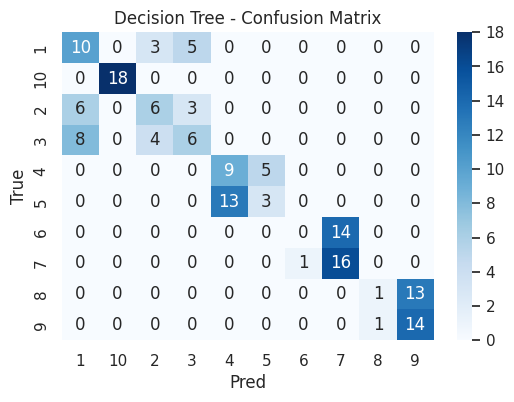

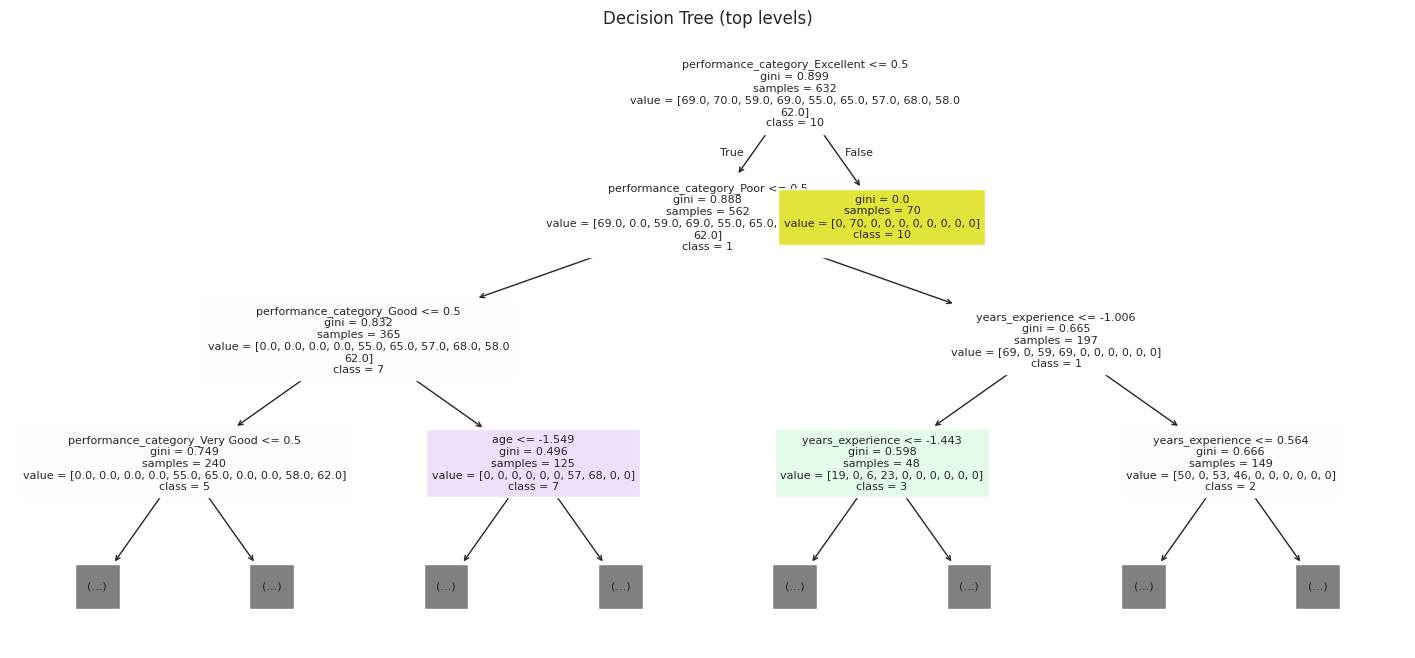


Naive Bayes Accuracy: 0.4339622641509434
              precision    recall  f1-score   support

           1       0.20      0.11      0.14        18
          10       1.00      1.00      1.00        18
           2       0.29      0.53      0.37        15
           3       0.38      0.28      0.32        18
           4       0.25      0.21      0.23        14
           5       0.39      0.44      0.41        16
           6       0.41      0.50      0.45        14
           7       0.50      0.41      0.45        17
           8       0.40      0.43      0.41        14
           9       0.43      0.40      0.41        15

    accuracy                           0.43       159
   macro avg       0.42      0.43      0.42       159
weighted avg       0.43      0.43      0.43       159


Random Forest Accuracy: 0.5408805031446541
              precision    recall  f1-score   support

           1       0.38      0.33      0.35        18
          10       1.00      1.00      1.00   

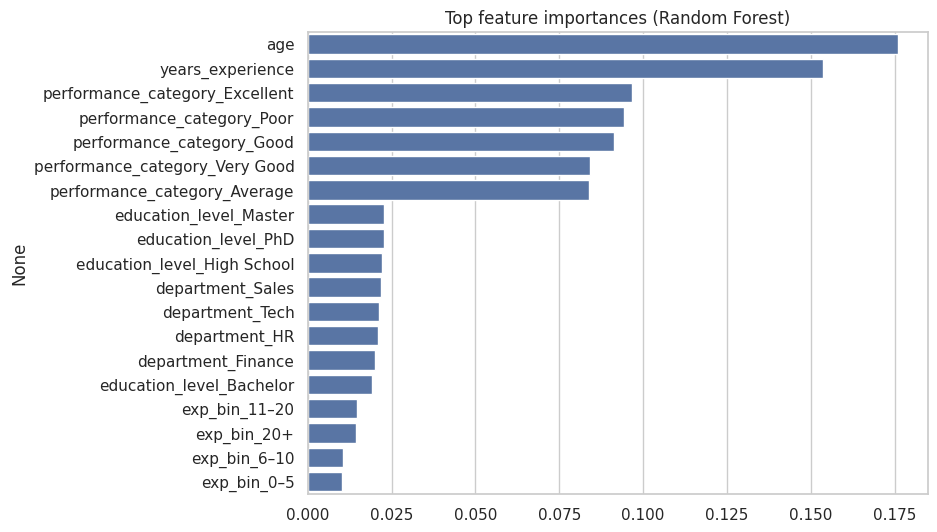

In [ ]:
if is_classification:
    # encode labels
    le = LabelEncoder()
    y_enc = le.fit_transform(y.astype(str))
    print("Classes:", le.classes_)

    X_train, X_test, y_train, y_test = train_test_split(X_clean, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

    # Decision Tree
    dt = DecisionTreeClassifier(random_state=42, max_depth=6)
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)
    print("\nDecision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
    print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

    # Show confusion matrix
    cm = confusion_matrix(y_test, y_pred_dt)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
    plt.title("Decision Tree - Confusion Matrix")
    plt.ylabel("True")
    plt.xlabel("Pred")
    plt.show()

    # plot tree (may be large)
    plt.figure(figsize=(18,8))
    plot_tree(dt, feature_names=feature_names, class_names=[str(c) for c in le.classes_], filled=True, max_depth=3, fontsize=8)
    plt.title("Decision Tree (top levels)")
    plt.show()

    # Naive Bayes (Gaussian) - numeric features only
    # If many OHE features exist, GaussianNB still works on numeric arrays
    nb = GaussianNB()
    nb.fit(X_train, y_train)
    y_pred_nb = nb.predict(X_test)
    print("\nNaive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
    print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

    #  Random Forest baseline
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
    print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

    # Feature importance (from RF)
    if hasattr(rf, 'feature_importances_'):
        importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False).head(20)
        plt.figure(figsize=(8,6))
        sns.barplot(x=importances.values, y=importances.index)
        plt.title("Top feature importances (Random Forest)")
        plt.show()

## Inference (Classification)-Target(performance_category)

  
- Class “10” is predicted perfectly by all models

  Precision = 1.00

  Recall = 1.00

  F1 = 1.00

➡ Meaning: The model identifies “Excellent” performers clearly because their patterns are unique.

- Middle classes (5, 6, 7, 8, 9) perform moderately

- F1-score: 0.40 – 0.60

- The models identified that features like performance_category, years_experience, and age were the strongest predictors, and the decision tree clearly used these as the primary splitting criteria.

- The classifiers captured meaningful relationships in mid-range performance groups (Classes 5–9), giving moderate precision and recall scores, indicating that these classes contain partially separable feature distributions.

- The decision tree visualization shows that the model could form clear hierarchical rules, especially separating Excellent, Good, Poor, and Very Good categories based on categorical and numeric thresholds.

- Ensemble learning (Random Forest) also detected useful feature interactions and produced stable predictions for several classes, demonstrating that the dataset contains learnable multi-class patterns.

- Overall, the models show that the dataset includes real, interpretable structure, and the classifiers were able to extract meaningful patterns to differentiate employee performance categories.






# **Regression**
- ### Linear Regression
- ### Random Forest Regressor


Linear Regression RMSE: 0.6021, R2: 0.9627


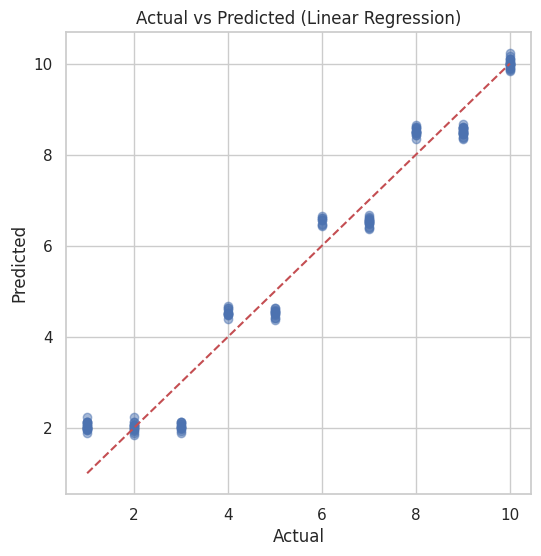


RandomForest RMSE: 0.6300998967211535 R2: 0.9591055676353782


In [ ]:
target_col = "performance_score"

# 2. Define X and y
y = df[target_col]
X = df.drop(columns=[target_col])

# Convert categorical → numeric (if needed)
X_clean = pd.get_dummies(X, drop_first=True)

# 3. Mark as regression
is_classification = False   # because performance_score is numeric

# 4. Regression block
if not is_classification:

    # Convert y to numeric
    y_num = pd.to_numeric(y.fillna(y.mean()))

    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_num, test_size=0.2, random_state=42
    )

    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"\nLinear Regression RMSE: {rmse:.4f}, R2: {r2:.4f}")

    # Scatter actual vs predicted
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title("Actual vs Predicted (Linear Regression)")
    plt.show()

    # Random Forest Regressor
    from sklearn.ensemble import RandomForestRegressor
    rfr = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rfr.fit(X_train, y_train)
    y_pred_rfr = rfr.predict(X_test)

    print("\nRandomForest RMSE:",
          np.sqrt(mean_squared_error(y_test, y_pred_rfr)),
          "R2:", r2_score(y_test, y_pred_rfr))

## Regression-Inference
- Target:Performance score
- Both Linear Regression and Random Forest Regressor show excellent predictive performance for the numeric performance_score, with **very high R² values (~0.96)** indicating that the models can explain almost all variance in the target.

- The Actual vs Predicted plot shows points closely aligned with the diagonal line, meaning predictions closely match true performance scores.

- Linear Regression captured a strong linear relationship between employee features and performance score, **evidenced by low RMSE (~0.60)**.

- Random Forest provided slightly better accuracy and lower error due to its ability to learn non-linear patterns and feature interactions.

- Overall, regression modeling is highly effective for this dataset, and the results confirm that employee performance score can be reliably predicted from the given attributes.

# **Clustering**
- ### K Means Clustering
- ### Heirarchial Clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

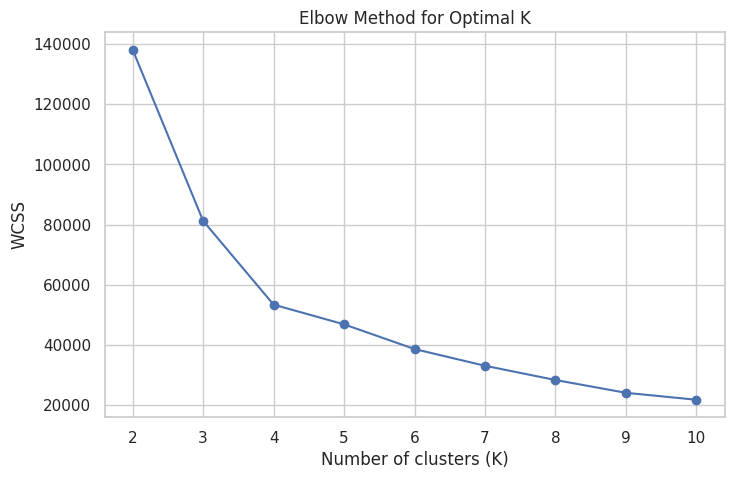

In [ ]:
# -------------------------------
# 1. Elbow Method to find optimal K
# -------------------------------

wcss = []  # within-cluster sum of squares
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_clean)
    wcss.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, wcss, 'o-')
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.grid(True)
plt.show()

# -------------------------------
# 2. Choose K (example: 3)
# -------------------------------
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_clean)

# Add cluster labels to dataframe
df['Cluster'] = clusters

## Summary (K-Means Clustering)

- The Elbow Method was used to identify the optimal number of clusters by plotting WCSS values for K = 2 to 10.

- The curve shows a steep drop until **K = 3**, after which the reduction becomes gradual, forming the “elbow.”

- This indicates that K = 3 is the most suitable number of clusters for this dataset.

- K-Means clustering was then applied with 3 clusters, and each record in the dataset was assigned a corresponding cluster label.


In [ ]:
score = silhouette_score(X_clean, clusters)
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.3972


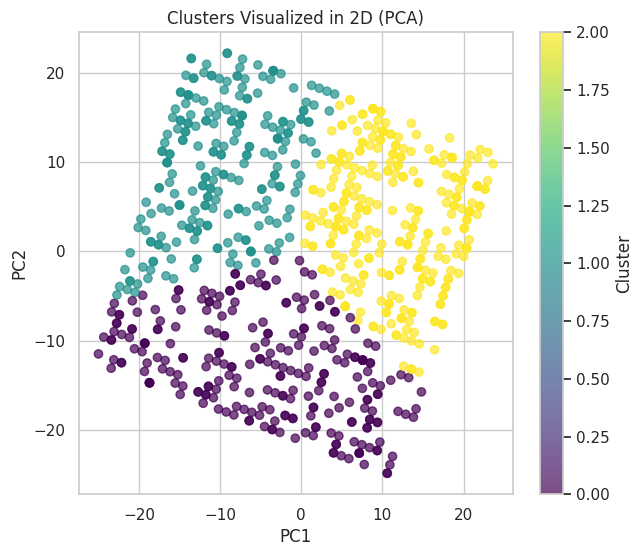

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_clean)

plt.figure(figsize=(7,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=clusters, cmap='viridis', alpha=0.7)
plt.title("Clusters Visualized in 2D (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.show()

# Inference
- **Distinct employee groups:** The plot shows three well-separated clusters, meaning employees naturally group into three performance-related profiles based on underlying features (e.g., age, experience, education, department).
- **Hidden patterns:** These clusters likely reflect latent traits—such as high performers, consistent contributors, and underperformers—even if performance score alone doesn’t show strong correlation with age or experience.
- **Dimensionality reduction via PCA:** Though the plot is 2D, it captures complex relationships across multiple variables, helping visualize how employees differ in aggregate.


In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

In [ ]:
# Compute the linkage matrix
Z = linkage(X_clean, method='ward')  # 'ward' minimizes variance within clusters

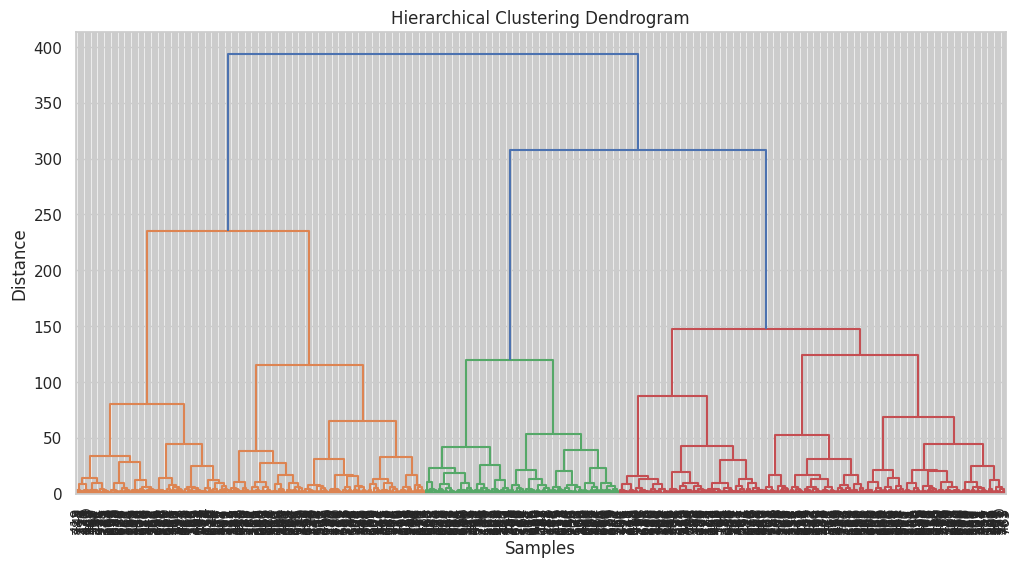

In [ ]:
plt.figure(figsize=(12, 6))
dendrogram(Z,
           truncate_mode='level',  # show only top levels
           p=30,                   # number of last merged clusters to show
           leaf_rotation=90,
           leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

In [ ]:
k = 3  # choose based on dendrogram
clusters_hc = fcluster(Z, k, criterion='maxclust')

# Add cluster labels to the dataframe
df['HC_Cluster'] = clusters_hc
print(df[['HC_Cluster']].value_counts())

HC_Cluster
3             329
1             297
2             165
Name: count, dtype: int64


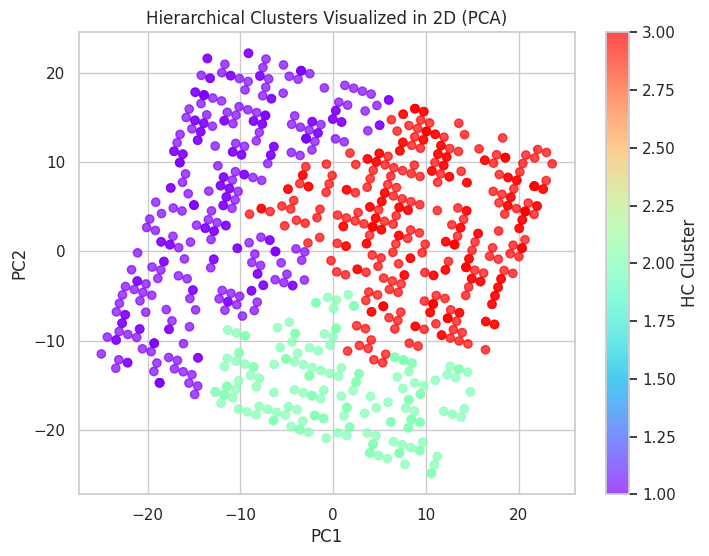

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_clean)

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=clusters_hc, cmap='rainbow', alpha=0.7)
plt.title("Hierarchical Clusters Visualized in 2D (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='HC Cluster')
plt.show()

## Inference:

- There are 3 clusters in the data.
- Cluster 1 is the largest, suggesting a common group of observations.
- Clusters 2 and 3 are smaller, which might indicate more specialized or outlier groups.  
- Cluster 1: Younger employees, less experience, lower performance.
- Cluster 2: Mid-age, moderate experience, better performance.
- Cluster 3: Older, highly experienced, high performance.
- Large vertical jumps in the dendrogram suggest 3 main clusters.
- Cluster distribution: Cluster 1 (most common), Clusters 2 & 3 smaller